# char_12 — Weakley-style transferability audit: is the deployed calibration
# being extrapolated to Addis?

## Purpose

Weakley, Takahama & Dillner (2018, *Aerosol Sci. Technol.* 52:9, 1048–1058) extended
FT-IR OC/EC calibrations from one PTFE-filter population (CSN) to another (FRM) and
diagnosed transferability by **comparing the two populations' spectral
distributions** — mean plus 5th/95th percentiles, raw and after the second-derivative
processing the calibration actually consumes — at the wavenumbers that carry the
prediction. A mere change of PTFE manufacturer added ~+2 % OC / +6 % EC error.

The ETAD dataset carries **deployed FTIR OC/EC values produced by calibrations
developed on US-network filters**. Addis aerosol vs the IMPROVE network is a far
larger population shift than Whatman vs MTL, and this repo happens to hold an actual
sample of the calibration-side population: **916 IMPROVE-site spectra** in the same
raw-absorbance form as the ETAD spectra. This notebook applies the paper's
diagnostics to that pair:

1. **Raw distributions** (their Figure 5a) — IMPROVE vs ETAD, full range.
2. **Processed distributions** (their Figure 5b/c) — Savitzky–Golay second
   derivatives in the two analytically pertinent regions, 3000–2800 and
   1850–1450 cm⁻¹.
3. **An envelope-escape score per filter** — how often each ETAD filter leaves the
   IMPROVE 5–95 % envelope where it matters, split by season and by the `char_06`
   anomaly class.
4. **The filter-lot effect** (their MTL-vs-Whatman analysis, transplanted) — ETAD
   lots 248 vs 251.
5. **A bonus outside the paper**: their derivative processing as a baseline-free
   robustness check of this folder's charcoal-matching headlines, which the README
   admits depended on the AIRSpec baseline.

## What cannot be replicated, and why

The full protocol calibrates spectra to **collocated TOR** — ETAD has none (that is
what the proposed dry-season quartz campaign would create). And the deployed model's
coefficients live in an R object (`pls-OC-2026-06-24.RDS`) this environment cannot
read, so "important wavenumbers" here means the paper's analytically pertinent
regions rather than a VIP selection. These diagnostics are therefore about the
**spectral-space premise** of the deployed numbers, not their accuracy.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from scipy.signal import savgol_filter

from charcoal_spectra import load_all, resample, band_area, BANDS
from etad_spectra import load_etad

PLOT_DIR = Path("output/plots/char12")
TABLE_DIR = Path("output/tables/char12")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#e34948"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"
IMPROVE_COLOR = SERIES[0]
LOT_COLORS = {248: SERIES[3], 251: SERIES[2]}

SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}


def stamp(fig, text):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)


# The paper's processing: 2nd-order Savitzky–Golay second derivative, 20-point window
# at their ~1.3 cm⁻¹ native spacing ≈ 26 cm⁻¹. On the 2 cm⁻¹ working grid used here,
# 13 points gives the same physical window.
SG_WINDOW, SG_ORDER = 13, 2

# The two analytically pertinent regions from their Figure 5b/c.
REGION_CH = (2800.0, 3000.0)     # aliphatic C–H stretch — carries much of OC and EC
REGION_CO = (1450.0, 1850.0)     # carbonyl / aromatic / organonitrate window


def second_derivative(X):
    return savgol_filter(X, SG_WINDOW, SG_ORDER, deriv=2, axis=1)

## Load the two populations onto one grid

The IMPROVE spectra come from `ftir-spectra-2026-06-24.csv` (raw absorbance, one row
per analysis, 141 IMPROVE sites, one year of sampling). The ETAD side is the same
239-filter cohort as every other notebook, in its **raw as-measured** form — no
AIRSpec, no offset correction — because the second derivative is applied to raw
spectra in the paper, and additive/linear baseline terms do not survive a second
derivative anyway. Both are interpolated to a common 2 cm⁻¹ grid over their shared
range, and compared in **absolute absorbance units**: a PLS model applies its
coefficients to these amplitudes directly, so amplitude — not just shape — is what
decides whether a prediction interpolates or extrapolates.

In [2]:
IMPROVE_CSV = (Path.home() / "Library/CloudStorage/GoogleDrive-ahzs645@gmail.com"
               / "My Drive/University/Research/Grad/Data/FTIR"
               / "ftir-spectra-2026-06-24.csv")

imp = pd.read_csv(IMPROVE_CSV)
wn_cols = [c for c in imp.columns if c not in ("AnalysisId", "FilterId",
                                               "SampleDate", "Site")]
wn_imp = np.array([float(c) for c in wn_cols])
X_imp_raw = imp[wn_cols].to_numpy(float)
imp_meta = imp[["AnalysisId", "FilterId", "SampleDate", "Site"]].copy()

etad_meta, X_etad_raw, wn_etad = load_etad(baselined=False)
etad_meta = etad_meta.copy()
etad_meta["season_label"] = etad_meta["season"].map(SEASON_MAP)

lo = np.ceil(max(wn_imp.min(), wn_etad.min())) + 2.0
hi = np.floor(min(wn_imp.max(), wn_etad.max())) - 2.0
GRID_FULL = np.arange(lo, hi + 1e-9, 2.0)

X_imp = resample(X_imp_raw, wn_imp, GRID_FULL)
X_etad = resample(X_etad_raw, wn_etad, GRID_FULL)
keep_imp = np.isfinite(X_imp).all(axis=1)
X_imp, imp_meta = X_imp[keep_imp], imp_meta.loc[keep_imp].reset_index(drop=True)
assert np.isfinite(X_etad).all()

# Lot and char_06 anomaly labels for the ETAD side.
lots = pd.read_csv(
    Path.home() / "Library/CloudStorage/GoogleDrive-ahzs645@gmail.com"
    / "My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/DAVIS/ETAD FTIR"
    / "etad_spectra_lotmap.csv")
etad_meta = etad_meta.merge(lots[["MediaId", "LotId"]].drop_duplicates("MediaId"),
                            on="MediaId", how="left")
char06 = pd.read_csv("output/tables/char06/per_filter_classification.csv")
etad_meta = etad_meta.merge(
    char06[["FilterId", "component"]],
    left_on="ExternalFilterId", right_on="FilterId", how="left")

print(f"IMPROVE spectra on the common grid : {len(X_imp)}  "
      f"({imp_meta['Site'].nunique()} sites, "
      f"{imp_meta['SampleDate'].min()[:10]} … {imp_meta['SampleDate'].max()[:10]})")
print(f"ETAD filters                       : {len(X_etad)}")
print(f"common grid                        : {GRID_FULL.min():.0f}–"
      f"{GRID_FULL.max():.0f} cm⁻¹ at 2 cm⁻¹")
print(f"\nETAD lots   : {etad_meta['LotId'].value_counts(dropna=False).to_dict()}")
print(f"char_06 tags: {etad_meta['component'].value_counts(dropna=False).to_dict()}")

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
IMPROVE spectra on the common grid : 916  (141 sites, 2022-05-17 … 2023-04-30)
ETAD filters                       : 239
common grid                        : 503–3995 cm⁻¹ at 2 cm⁻¹

ETAD lots   : {251.0: 156, nan: 49, 248.0: 34}
char_06 tags: {'normal': 141, 'low-similarity': 98}


## 1. Raw distributions — their Figure 5a

Mean (solid) and 5th/95th percentiles (shaded) of each population, raw absorbance,
full shared range. In the paper the two curves nearly coincide and the argument is
about subtle percentile mismatches. Here the question is coarser: are the two
populations even on the same absorbance scale?

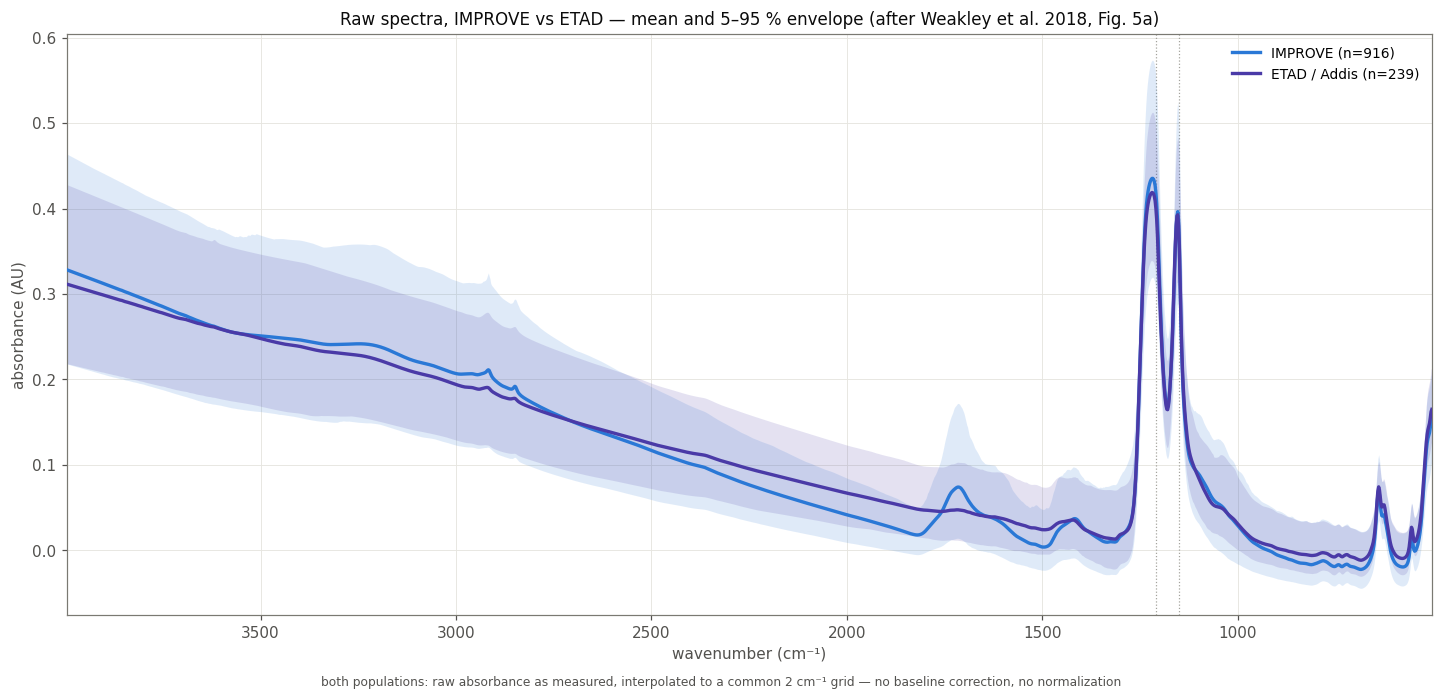

,median absorbance at 2000 cm⁻¹ (featureless),median PTFE C–F peak (~1210 cm⁻¹)
IMPROVE,0.033,0.405
ETAD,0.063,0.399


In [3]:
fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
for X, color, lab in [(X_imp, IMPROVE_COLOR, f"IMPROVE (n={len(X_imp)})"),
                      (X_etad, ADDIS_COLOR, f"ETAD / Addis (n={len(X_etad)})")]:
    q5, q95 = np.percentile(X, [5, 95], axis=0)
    ax.fill_between(GRID_FULL, q5, q95, color=color, alpha=0.15, lw=0, zorder=2)
    ax.plot(GRID_FULL, X.mean(0), color=color, lw=2.2, zorder=4, label=lab)
for wn0 in (1150, 1210):
    ax.axvline(wn0, color=MUTED, lw=0.8, ls=":", zorder=1)
ax.set_xlim(GRID_FULL.max(), GRID_FULL.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("absorbance (AU)", color=INK2)
ax.set_title("Raw spectra, IMPROVE vs ETAD — mean and 5–95 % envelope "
             "(after Weakley et al. 2018, Fig. 5a)", color=INK)
ax.legend(fontsize=9, loc="upper right")
stamp(fig, "both populations: raw absorbance as measured, interpolated to a common "
           "2 cm⁻¹ grid — no baseline correction, no normalization")
fig.savefig(PLOT_DIR / "01_raw_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

scatter_proxy = pd.DataFrame({
    "median absorbance at 2000 cm⁻¹ (featureless)": [
        np.median(X_imp[:, np.argmin(np.abs(GRID_FULL - 2000))]),
        np.median(X_etad[:, np.argmin(np.abs(GRID_FULL - 2000))])],
    "median PTFE C–F peak (~1210 cm⁻¹)": [
        np.median(X_imp[:, np.argmin(np.abs(GRID_FULL - 1210))]),
        np.median(X_etad[:, np.argmin(np.abs(GRID_FULL - 1210))])],
}, index=["IMPROVE", "ETAD"]).round(3)
display(scatter_proxy)
scatter_proxy.to_csv(TABLE_DIR / "raw_scale_comparison.csv")

## 2. Processed distributions — their Figure 5b/c

The calibration does not see raw spectra; it sees **second derivatives** (2nd-order
Savitzky–Golay, ~26 cm⁻¹ window — reproduced here as 13 points on the 2 cm⁻¹ grid).
These are the units in which "inside or outside the calibration population" is
actually decided. Shown for the paper's two pertinent regions, with the features
they single out marked: the 2960 cm⁻¹ CH₃ antisymmetric stretch used for EC, and
1630 cm⁻¹ where they found the poorest CSN/FRM correspondence.

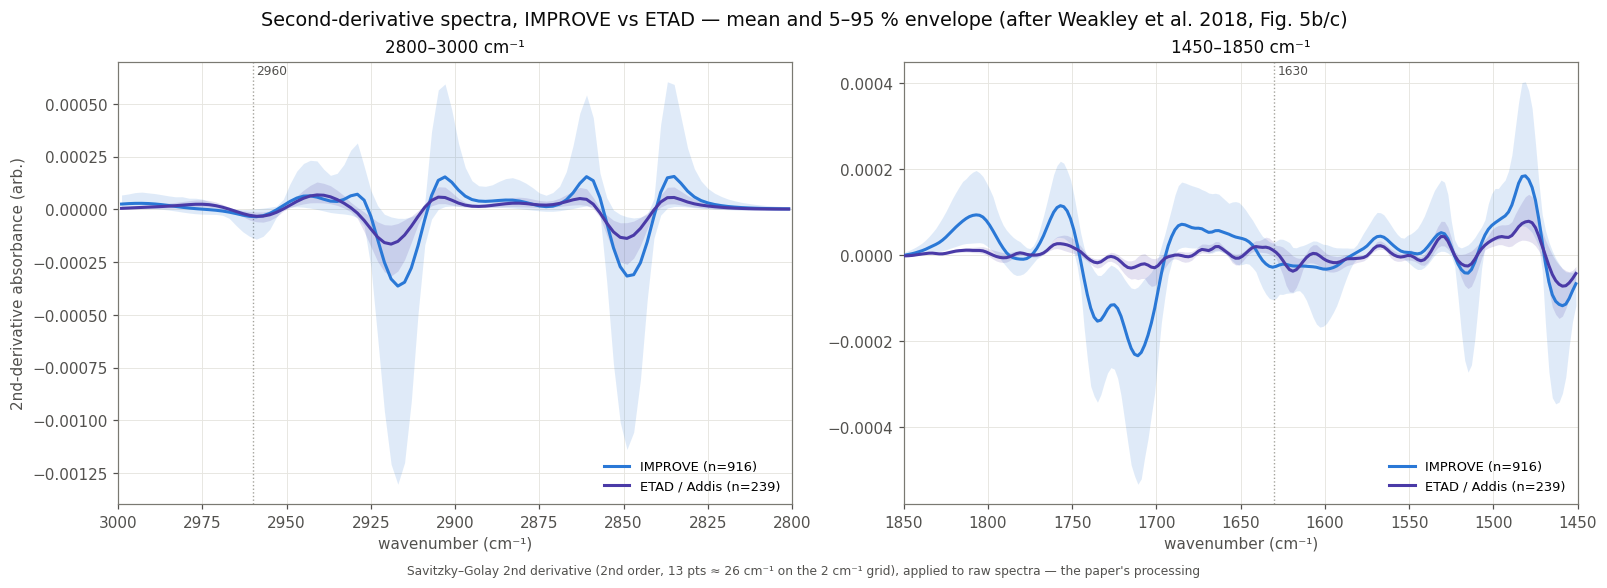

In [4]:
D_imp = second_derivative(X_imp)
D_etad = second_derivative(X_etad)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5), constrained_layout=True)
for ax, (rlo, rhi), marks in [(axes[0], REGION_CH, [2960]),
                              (axes[1], REGION_CO, [1630])]:
    m = (GRID_FULL >= rlo) & (GRID_FULL <= rhi)
    for D, color, lab in [(D_imp, IMPROVE_COLOR, f"IMPROVE (n={len(D_imp)})"),
                          (D_etad, ADDIS_COLOR, f"ETAD / Addis (n={len(D_etad)})")]:
        q5, q95 = np.percentile(D[:, m], [5, 95], axis=0)
        ax.fill_between(GRID_FULL[m], q5, q95, color=color, alpha=0.15, lw=0, zorder=2)
        ax.plot(GRID_FULL[m], D[:, m].mean(0), color=color, lw=2.0, zorder=4, label=lab)
    for wn0 in marks:
        ax.axvline(wn0, color=MUTED, lw=0.9, ls=":", zorder=1)
        ax.annotate(f"{wn0}", xy=(wn0, ax.get_ylim()[1]), xytext=(2, -2),
                    textcoords="offset points", fontsize=8, color=INK2, va="top")
    ax.set_xlim(rhi, rlo)
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
    ax.set_title(f"{rlo:.0f}–{rhi:.0f} cm⁻¹", color=INK)
    ax.legend(fontsize=8.5, loc="lower right")
axes[0].set_ylabel("2nd-derivative absorbance (arb.)", color=INK2)
fig.suptitle("Second-derivative spectra, IMPROVE vs ETAD — mean and 5–95 % envelope "
             "(after Weakley et al. 2018, Fig. 5b/c)", fontsize=12.5, color=INK)
stamp(fig, "Savitzky–Golay 2nd derivative (2nd order, 13 pts ≈ 26 cm⁻¹ on the "
           "2 cm⁻¹ grid), applied to raw spectra — the paper's processing")
fig.savefig(PLOT_DIR / "02_derivative_distributions.png", dpi=160,
            bbox_inches="tight")
plt.show()

## 3. How far outside the calibration population does each ETAD filter sit?

Per-filter **envelope-escape score**: the fraction of wavenumbers in the two
pertinent regions where a filter's second-derivative value lies outside the IMPROVE
5–95 % envelope. By construction an IMPROVE spectrum escapes its own population's
envelope ~10 % of the time — that is the null to read everything against.

,n,median escape,90th pct,share > 2× null
IMPROVE (null ≈ 0.10),916,0.043,0.245,0.128
ETAD — all,239,0.267,0.343,0.958
ETAD — dry season,105,0.283,0.350,0.971
ETAD — Belg,61,0.283,0.347,0.984
ETAD — Kiremt,73,0.230,0.291,0.918
ETAD — char_06 anomalous,98,0.278,0.350,0.980
ETAD — char_06 normal,141,0.257,0.340,0.943


ETAD vs IMPROVE escape: Mann–Whitney p = 8.13e-84


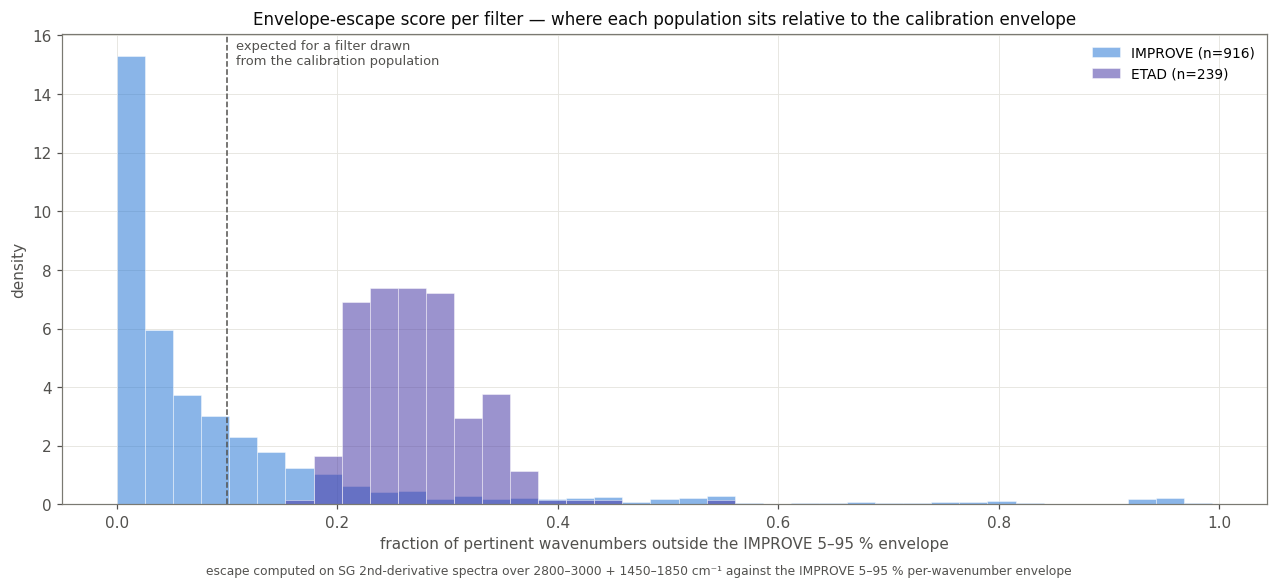

In [5]:
pert = ((GRID_FULL >= REGION_CH[0]) & (GRID_FULL <= REGION_CH[1])) | \
       ((GRID_FULL >= REGION_CO[0]) & (GRID_FULL <= REGION_CO[1]))
env_lo, env_hi = np.percentile(D_imp[:, pert], [5, 95], axis=0)


def escape(D):
    P = D[:, pert]
    return ((P < env_lo) | (P > env_hi)).mean(axis=1)


esc_imp = escape(D_imp)
esc_etad = escape(D_etad)
etad_meta["escape"] = esc_etad

groups = {
    "IMPROVE (null ≈ 0.10)": esc_imp,
    "ETAD — all": esc_etad,
}
for s, lab in [("Dry Season", "ETAD — dry season"),
               ("Belg Rainy Season", "ETAD — Belg"),
               ("Kiremt Rainy Season", "ETAD — Kiremt")]:
    groups[lab] = esc_etad[(etad_meta["season_label"] == s).to_numpy()]
for comp, lab in [("low-similarity", "ETAD — char_06 anomalous"),
                  ("normal", "ETAD — char_06 normal")]:
    groups[lab] = esc_etad[(etad_meta["component"] == comp).to_numpy()]

esc_tbl = pd.DataFrame({
    "n": {k: len(v) for k, v in groups.items()},
    "median escape": {k: np.median(v) for k, v in groups.items()},
    "90th pct": {k: np.percentile(v, 90) for k, v in groups.items()},
    "share > 2× null": {k: (v > 0.20).mean() for k, v in groups.items()},
})
display(esc_tbl.round(3))
esc_tbl.round(4).to_csv(TABLE_DIR / "escape_by_group.csv")

mw = stats.mannwhitneyu(esc_etad, esc_imp)
print(f"ETAD vs IMPROVE escape: Mann–Whitney p = {mw.pvalue:.2e}")

fig, ax = plt.subplots(figsize=(11.5, 5), constrained_layout=True)
bins = np.linspace(0, max(esc_etad.max(), esc_imp.max()) + 0.02, 40)
ax.hist(esc_imp, bins=bins, density=True, color=IMPROVE_COLOR, alpha=0.55,
        label=f"IMPROVE (n={len(esc_imp)})", edgecolor="white", linewidth=0.5)
ax.hist(esc_etad, bins=bins, density=True, color=ADDIS_COLOR, alpha=0.55,
        label=f"ETAD (n={len(esc_etad)})", edgecolor="white", linewidth=0.5)
ax.axvline(0.10, color=INK2, lw=1, ls="--")
ax.annotate("expected for a filter drawn\nfrom the calibration population",
            xy=(0.10, ax.get_ylim()[1]), xytext=(6, -4), textcoords="offset points",
            fontsize=8.5, color=INK2, va="top")
ax.set_xlabel("fraction of pertinent wavenumbers outside the IMPROVE 5–95 % envelope",
              color=INK2)
ax.set_ylabel("density", color=INK2)
ax.set_title("Envelope-escape score per filter — where each population sits relative "
             "to the calibration envelope", color=INK)
ax.legend(fontsize=9)
stamp(fig, "escape computed on SG 2nd-derivative spectra over 2800–3000 + "
           "1450–1850 cm⁻¹ against the IMPROVE 5–95 % per-wavenumber envelope")
fig.savefig(PLOT_DIR / "03_escape_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. The filter-lot effect, transplanted

The paper's second question — does the collection substrate itself shift the
spectra? — maps onto the two ETAD PTFE lots. Lot 248 is dry-season-heavy, so the
comparison is run twice: over all filters (confounded) and **within the dry season
only** (the paper-style controlled contrast, same logic as `char_06`).

,n lot 248,n lot 251,median escape 248,median escape 251,Mann–Whitney p
subset,,,,,
all filters,34,156,0.29,0.2567,0.0111
dry season only,27,46,0.29,0.2883,0.9453


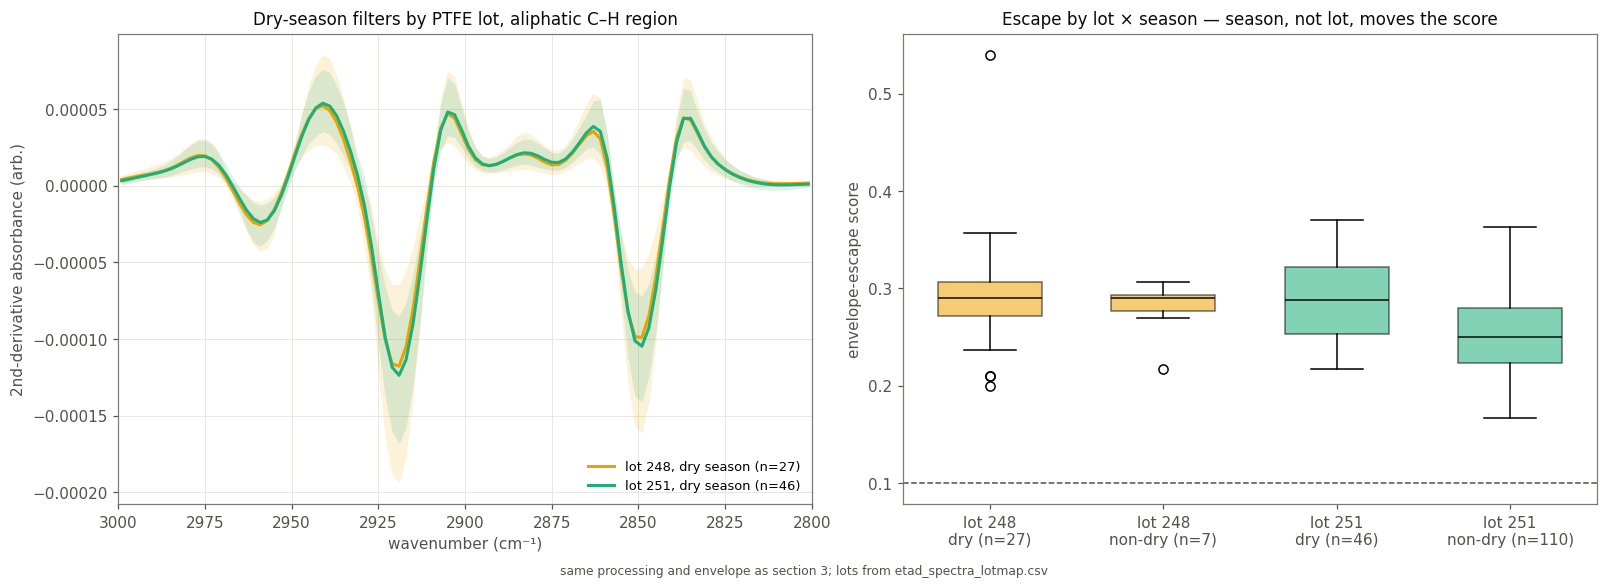

In [6]:
has_lot = etad_meta["LotId"].notna().to_numpy()
lot = etad_meta["LotId"].to_numpy()
is_dry = (etad_meta["season_label"] == "Dry Season").to_numpy()

rows = []
for label, base in [("all filters", has_lot), ("dry season only", has_lot & is_dry)]:
    a = esc_etad[base & (lot == 248)]
    b = esc_etad[base & (lot == 251)]
    rows.append({
        "subset": label, "n lot 248": len(a), "n lot 251": len(b),
        "median escape 248": np.median(a), "median escape 251": np.median(b),
        "Mann–Whitney p": stats.mannwhitneyu(a, b).pvalue,
    })
lot_tbl = pd.DataFrame(rows).set_index("subset")
display(lot_tbl.round(4))
lot_tbl.round(6).to_csv(TABLE_DIR / "lot_effect.csv")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5), constrained_layout=True)

ax = axes[0]
m = (GRID_FULL >= REGION_CH[0]) & (GRID_FULL <= REGION_CH[1])
for lid in (248, 251):
    sel = has_lot & (lot == lid) & is_dry
    q5, q95 = np.percentile(D_etad[sel][:, m], [5, 95], axis=0)
    ax.fill_between(GRID_FULL[m], q5, q95, color=LOT_COLORS[lid], alpha=0.15, lw=0)
    ax.plot(GRID_FULL[m], D_etad[sel][:, m].mean(0), color=LOT_COLORS[lid], lw=2.0,
            label=f"lot {lid}, dry season (n={sel.sum()})")
ax.set_xlim(REGION_CH[1], REGION_CH[0])
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("2nd-derivative absorbance (arb.)", color=INK2)
ax.set_title("Dry-season filters by PTFE lot, aliphatic C–H region", color=INK)
ax.legend(fontsize=8.5, loc="lower right")

ax = axes[1]
data, labels, colors = [], [], []
for lid in (248, 251):
    for dlab, dm in [("dry", is_dry), ("non-dry", ~is_dry)]:
        sel = has_lot & (lot == lid) & dm
        if sel.sum():
            data.append(esc_etad[sel])
            labels.append(f"lot {lid}\n{dlab} (n={sel.sum()})")
            colors.append(LOT_COLORS[lid])
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.6)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.55)
for med in bp["medians"]:
    med.set_color(INK)
ax.axhline(0.10, color=INK2, lw=1, ls="--")
ax.set_ylabel("envelope-escape score", color=INK2)
ax.set_title("Escape by lot × season — season, not lot, moves the score", color=INK)
ax.grid(False)

stamp(fig, "same processing and envelope as section 3; lots from "
           "etad_spectra_lotmap.csv")
fig.savefig(PLOT_DIR / "04_lot_effect.png", dpi=160, bbox_inches="tight")
plt.show()

### 4b. The same lot comparison in the AIRSpec-baselined view

The derivative space above is what the calibration sees; this is what the *folder*
sees — the AIRSpec-baselined, area-normalized representation used throughout
`char_10`. Left panel: the two lots over all filters, where lot and season are
confounded (lot 248 is 27/34 dry-season). Right panel: **dry-season filters only**,
the controlled contrast. If the substrate mattered, the two curves on the right
would separate.

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


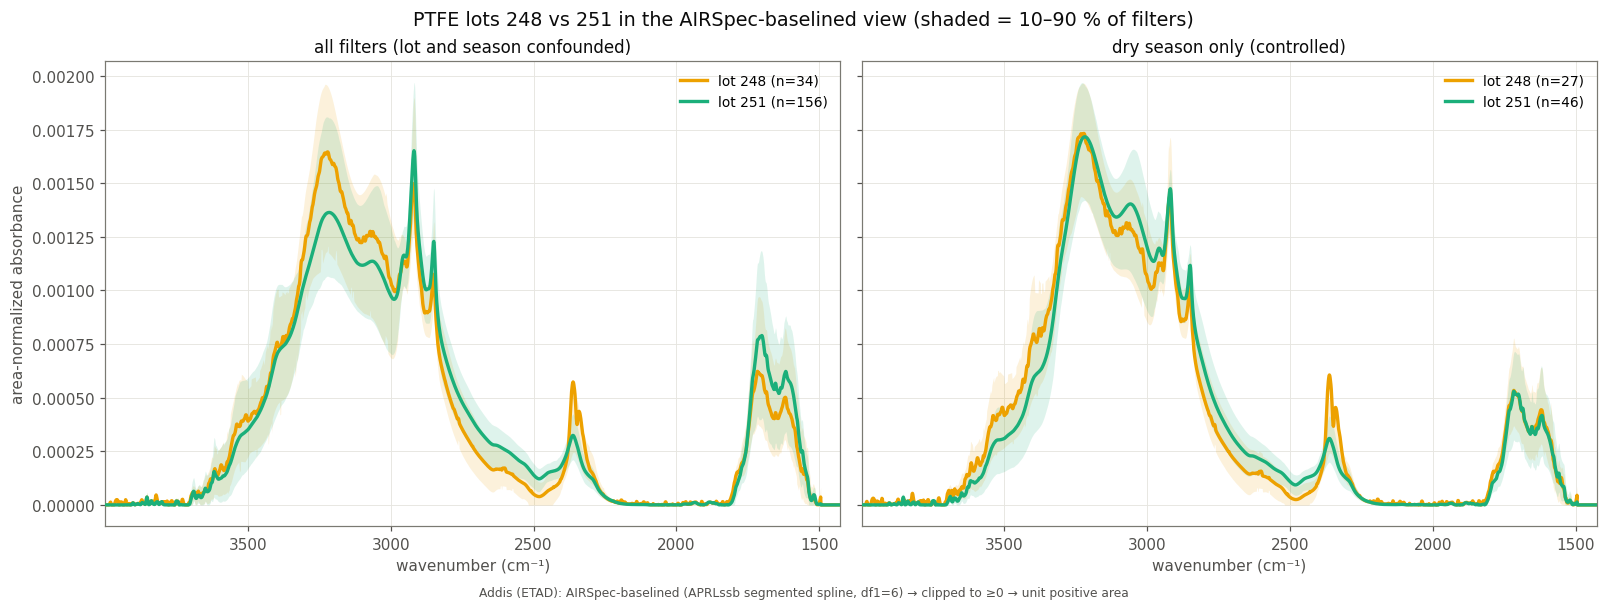

In [7]:
bmeta, X_b, wn_b = load_etad(baselined=True)
bmeta = bmeta.copy()
bmeta["season_label"] = bmeta["season"].map(SEASON_MAP)
bmeta = bmeta.merge(lots[["MediaId", "LotId"]].drop_duplicates("MediaId"),
                    on="MediaId", how="left")
wn_b_asc = np.sort(wn_b)


def area_norm_b(X):
    # char_10's convention on AIRSpec-baselined Addis spectra: clip, unit positive area.
    pos = np.clip(X, 0, None)
    a = np.trapezoid(pos[:, np.argsort(wn_b)], wn_b_asc, axis=1)[:, None]
    a[a == 0] = np.nan
    return pos / np.abs(a)


Xb_shape = area_norm_b(X_b)
lot_b = bmeta["LotId"].to_numpy()
dry_b = (bmeta["season_label"] == "Dry Season").to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), sharey=True,
                         constrained_layout=True)
for ax, base, title in [(axes[0], np.ones(len(bmeta), bool),
                         "all filters (lot and season confounded)"),
                        (axes[1], dry_b, "dry season only (controlled)")]:
    for lid in (248, 251):
        sel = base & (lot_b == lid)
        q1, q3 = np.nanpercentile(Xb_shape[sel], [10, 90], axis=0)
        ax.fill_between(wn_b, q1, q3, color=LOT_COLORS[lid], alpha=0.14, lw=0,
                        zorder=2)
        ax.plot(wn_b, np.nanmean(Xb_shape[sel], axis=0), color=LOT_COLORS[lid],
                lw=2.2, zorder=4, label=f"lot {lid} (n={sel.sum()})")
    ax.set_xlim(wn_b_asc.max(), wn_b_asc.min())
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
    ax.set_title(title, color=INK)
    ax.legend(fontsize=9, loc="upper right")
axes[0].set_ylabel("area-normalized absorbance", color=INK2)
fig.suptitle("PTFE lots 248 vs 251 in the AIRSpec-baselined view "
             "(shaded = 10–90 % of filters)", fontsize=12.5, color=INK)
stamp(fig, "Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
           "→ clipped to ≥0 → unit positive area")
fig.savefig(PLOT_DIR / "04b_lot_airspec_view.png", dpi=160, bbox_inches="tight")
plt.show()

In [8]:
sel248, sel251 = dry_b & (lot_b == 248), dry_b & (lot_b == 251)
m248 = np.nanmean(Xb_shape[sel248], axis=0)
m251 = np.nanmean(Xb_shape[sel251], axis=0)
z248 = (m248 - m248.mean()) / m248.std()
z251 = (m251 - m251.mean()) / m251.std()
r_lots = float(z248 @ z251 / m248.size)
print(f"dry-season mean-spectrum correlation, lot 248 vs 251: r = {r_lots:.3f}")
print("(char_10 scale: the three *seasons* correlate 0.94–0.98 with each other)")

rows = []
for name, window in BANDS.items():
    if window[0] < wn_b_asc.min():
        continue
    areas = band_area(Xb_shape, wn_b, window) * 1e4
    rows.append({
        "band": name, "window (cm⁻¹)": f"{window[0]}–{window[1]}",
        "lot 248 median (×10⁻⁴)": np.nanmedian(areas[sel248]),
        "lot 251 median (×10⁻⁴)": np.nanmedian(areas[sel251]),
        "Mann–Whitney p (within dry)": stats.mannwhitneyu(
            areas[sel248], areas[sel251]).pvalue,
    })
lot_bands = pd.DataFrame(rows).set_index("band")
display(lot_bands.round(4))
lot_bands.round(6).to_csv(TABLE_DIR / "lot_bands_within_dry.csv")

dry-season mean-spectrum correlation, lot 248 vs 251: r = 0.987
(char_10 scale: the three *seasons* correlate 0.94–0.98 with each other)


,window (cm⁻¹),lot 248 median (×10⁻⁴),lot 251 median (×10⁻⁴),Mann–Whitney p (within dry)
band,,,,
OH / NH stretch,3200–3400,12.9401,11.3710,0.0015
aromatic CH stretch,3040–3070,13.3099,14.2131,0.0617
aliphatic CH stretch,2850–2950,10.5737,11.3838,0.0134
carbonyl C=O,1700–1750,4.2825,4.4101,0.6354
aromatic C=C,1580–1620,3.3654,3.1528,0.5717


## 5. Bonus — the paper's processing as a baseline-free check on the charcoal results

The README concedes the charcoal conclusions depended on the AIRSpec baseline
(r = 0.60 → 0.78 when the baseline was fixed). The paper's second-derivative
processing needs **no baseline at all** — additive and linear terms vanish, and the
broad scattering background is strongly suppressed. If `char_02`/`char_08`'s
headlines survive on derivative spectra computed from the **raw** ETAD data, they do
not rest on the AIRSpec choice.

Recomputed here: the furnace-vs-fire contrast (char_08: median best r 0.776 vs
0.566, gap 0.211, ~0 % of filters favouring fire char) and the charcoal-to-charcoal
similarity ceiling (char_02: ~0.99 vs Addis-to-charcoal 0.78).

,SNV chain (char_02/08),"2nd derivative, no baseline","2nd derivative, CO₂ region masked"
median best r — furnace,0.776,0.626,0.630
median best r — fire,0.566,0.716,0.753
furnace − fire gap,0.211,-0.090,-0.123
% filters favouring fire,0.400,97.071,99.582
charcoal-to-charcoal ceiling,0.990,0.992,NaN


furnace vs fire on derivative spectra: Wilcoxon p = 1.81e-40
dry vs non-dry, furnace best r (derivative): 0.581 vs 0.664


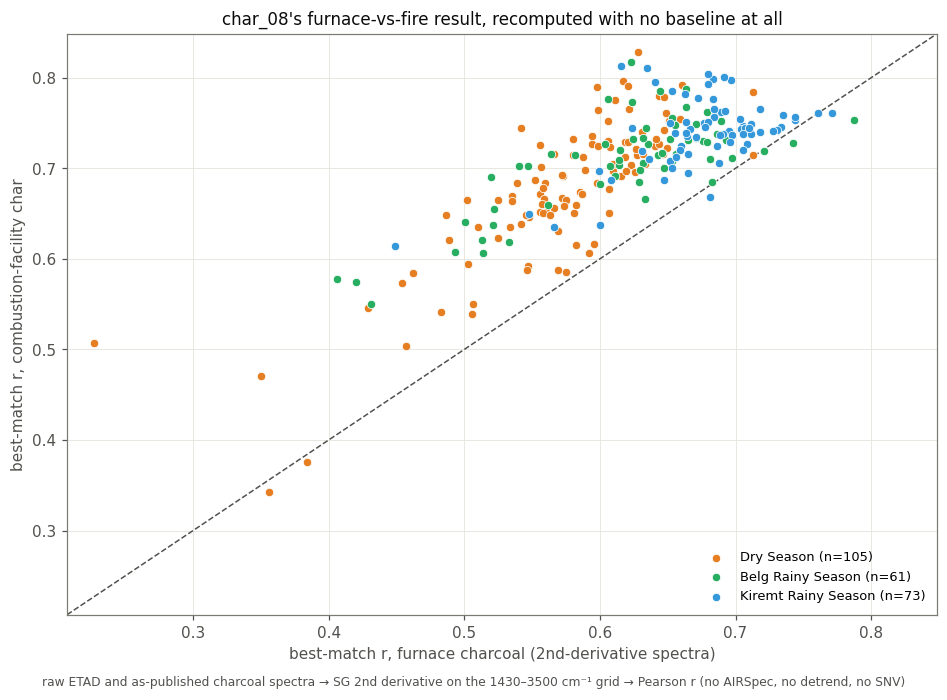

In [9]:
GRID_CHAR = np.arange(1430.0, 3500.0 + 1e-9, 2.0)
sets = load_all()


def deriv_on(X, wn):
    Xr = resample(X, wn, GRID_CHAR)
    keep = np.isfinite(Xr).all(axis=1)
    return second_derivative(Xr[keep])


D_fur = deriv_on(sets["minatre_ref"].X, sets["minatre_ref"].wn)
D_fire = deriv_on(sets["minatre_burn"].X, sets["minatre_burn"].wn)
D_addis_char = second_derivative(resample(X_etad_raw, wn_etad, GRID_CHAR))


def zrows(X):
    return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)


Za = zrows(D_addis_char)
best_fur = (Za @ zrows(D_fur).T / GRID_CHAR.size).max(axis=1)
best_fire = (Za @ zrows(D_fire).T / GRID_CHAR.size).max(axis=1)

# Control: derivative correlations weight narrow features heavily, and the gas-phase
# CO2 band near 2350 cm-1 is exactly that (char_10 flagged spikes there). Recompute
# with 2280-2400 excluded to make sure nothing below hinges on it.
co2_free = ~((GRID_CHAR >= 2280) & (GRID_CHAR <= 2400))


def zrows_m(X):
    Xm = X[:, co2_free]
    return (Xm - Xm.mean(1, keepdims=True)) / Xm.std(1, keepdims=True)


best_fur_m = (zrows_m(D_addis_char) @ zrows_m(D_fur).T / co2_free.sum()).max(axis=1)
best_fire_m = (zrows_m(D_addis_char) @ zrows_m(D_fire).T / co2_free.sum()).max(axis=1)

# Charcoal-to-charcoal ceiling: each furnace spectrum against the rest of its class.
Zf = zrows(D_fur)
Rff = Zf @ Zf.T / GRID_CHAR.size
np.fill_diagonal(Rff, -np.inf)
ceiling = np.median(Rff.max(axis=1))

wil = stats.wilcoxon(best_fur, best_fire)
season_arr = etad_meta["season_label"].to_numpy()
dry_mask = season_arr == "Dry Season"

deriv_tbl = pd.DataFrame({
    "SNV chain (char_02/08)": {
        "median best r — furnace": 0.776, "median best r — fire": 0.566,
        "furnace − fire gap": 0.211, "% filters favouring fire": 0.4,
        "charcoal-to-charcoal ceiling": 0.99},
    "2nd derivative, no baseline": {
        "median best r — furnace": np.median(best_fur),
        "median best r — fire": np.median(best_fire),
        "furnace − fire gap": np.median(best_fur) - np.median(best_fire),
        "% filters favouring fire": (best_fire > best_fur).mean() * 100,
        "charcoal-to-charcoal ceiling": ceiling},
    "2nd derivative, CO₂ region masked": {
        "median best r — furnace": np.median(best_fur_m),
        "median best r — fire": np.median(best_fire_m),
        "furnace − fire gap": np.median(best_fur_m) - np.median(best_fire_m),
        "% filters favouring fire": (best_fire_m > best_fur_m).mean() * 100,
        "charcoal-to-charcoal ceiling": np.nan},
})
display(deriv_tbl.round(3))
deriv_tbl.round(4).to_csv(TABLE_DIR / "derivative_robustness.csv")
print(f"furnace vs fire on derivative spectra: Wilcoxon p = {wil.pvalue:.2e}")
print(f"dry vs non-dry, furnace best r (derivative): "
      f"{np.median(best_fur[dry_mask]):.3f} vs {np.median(best_fur[~dry_mask]):.3f}")

fig, ax = plt.subplots(figsize=(8.5, 6), constrained_layout=True)
for s, color in SEASON_COLORS.items():
    m = season_arr == s
    ax.scatter(best_fur[m], best_fire[m], s=30, c=color, edgecolor="white",
               linewidth=0.5, label=f"{s} (n={m.sum()})", zorder=3)
lims = [min(best_fur.min(), best_fire.min()) - 0.02,
        max(best_fur.max(), best_fire.max()) + 0.02]
ax.plot(lims, lims, color=INK2, lw=1, ls="--", zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("best-match r, furnace charcoal (2nd-derivative spectra)", color=INK2)
ax.set_ylabel("best-match r, combustion-facility char", color=INK2)
ax.set_title("char_08's furnace-vs-fire result, recomputed with no baseline at all",
             color=INK)
ax.legend(fontsize=8.5, loc="lower right")
stamp(fig, "raw ETAD and as-published charcoal spectra → SG 2nd derivative on the "
           "1430–3500 cm⁻¹ grid → Pearson r (no AIRSpec, no detrend, no SNV)")
fig.savefig(PLOT_DIR / "05_derivative_furnace_vs_fire.png", dpi=160,
            bbox_inches="tight")
plt.show()

## Takeaways

- **Same substrate, heavier deposits.** The two populations share the PTFE filter
  (median C–F peak 0.405 IMPROVE vs 0.399 ETAD — a clean internal control), but ETAD
  carries roughly **twice** the scattering background (median absorbance at the
  featureless 2000 cm⁻¹ point: 0.063 vs 0.033). Addis deposits are simply heavier
  than anything the calibration population contains.
- **The deployed OC/EC values rest on extrapolation — as a population property.** In
  the second-derivative space the calibration actually consumes, the median ETAD
  filter sits outside the IMPROVE 5–95 % envelope at **27 %** of the pertinent
  wavenumbers, against an IMPROVE self-consistency median of **4 %**
  (Mann–Whitney p = 8e-84); **96 %** of ETAD filters exceed twice the nominal null.
  Crucially this is *not* the dry-season anomaly wearing another hat: Kiremt is the
  mildest season at 0.23 and the `char_06`-anomalous filters (0.278) barely differ
  from normal ones (0.257). Weakley et al. saw +2 % OC / +6 % EC error from a mere
  filter-manufacturer change; the population shift here is qualitatively larger, so
  deployed ETAD OC/EC should be quoted with an extrapolation caveat until a local or
  transfer calibration exists — which is exactly what the proposed collocated
  dry-season TOR campaign would provide.
- **The lot effect is season in disguise — with a small honest residue.** Escape
  differs by PTFE lot over all filters (p = 0.011) but not within the dry season
  (p = 0.95), the same resolution `char_06` reached. In the AIRSpec-baselined view
  (4b) the two lots' dry-season mean spectra are nearly one curve (r = 0.987 —
  tighter than any *season* pair in `char_10`), but two bands do separate mildly
  within the dry season: lot 248 runs ~14 % higher in O–H/N–H (p = 0.0015) and ~7 %
  lower in aliphatic C–H (p = 0.013). That is an order of magnitude smaller than the
  seasonal contrasts, and since the two lots' filters were not deployed over the
  same dates it may reflect within-season timing as much as substrate. Nothing here
  changes any conclusion built on season or anomaly.
- **The derivative check upholds two charcoal headlines and overturns one.**
  With no baseline at all (raw spectra → second derivative), *charcoal-adjacent,
  not charcoal* survives — Addis best-match r 0.63–0.75 against a
  charcoal-to-charcoal ceiling of **0.992** — and the dry season still matches worse
  (furnace best r 0.581 dry vs 0.664 non-dry). But **char_08's furnace-over-fire
  ordering flips**: on derivative spectra the combustion-facility char beats furnace
  charcoal for **97 %** of filters (median 0.716 vs 0.626, Wilcoxon p = 2e-40), and
  masking the CO₂ region strengthens the flip (100 %, gap −0.123) — so it is not a
  narrow-band artifact. The ordering is **representation-dependent**: the SNV chain
  compares broad band shapes and prefers furnace charcoal; the derivative chain
  compares narrow features and prefers fire char. `char_09` showed the ordering was
  robust *within* the SNV chain; it is not robust *across* chains, which strengthens
  `char_08`'s own caution that no produced-by inference should be hung on it.

**What this adds to the folder.** The AIRSpec-dependence the README warns about is
now quantified from the other direction: the results that only need *shape
similarity in the large* (charcoal-adjacent, the dry-season deficit) hold under a
baseline-free processing chain, while the one result that ranked *kinds* of char
does not. And the transferability audit gives the phase-3 calibration work a
concrete, per-filter measure of how far outside the deployed calibration's world
every Addis filter sits.